# GAME 1

# WIFI

In [1]:
#12
from pynq.lib import Wifi
import os
import time

ssid = "Taha" 
pwd = "rgbj9400"

#ssid = "Misha" 
#pwd = "Hotspot1802!"

print(f"Attempting to connect to {ssid}...")

port_wifi = Wifi()
port_wifi.connect(ssid, pwd)

time.sleep(5)

print("Connection finished. Active IPs:")
os.system("hostname -I")

Attempting to connect to Taha...


/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/lib/wifi.py:170: UserWarning: A connection is already established. You can force a new connection by setting the 'force' option to 'True'.
  warnings.warn("A connection is already established. You can force "


Connection finished. Active IPs:
192.168.2.99 10.194.71.194 


0

# MAZE GENERATING

In [59]:
BIT_PATH = '/home/xilinx/jupyter_notebooks/kruskal.bit'
HWH_PATH = '/home/xilinx/jupyter_notebooks/kruskal.hwh'
ROWS = 5
COLS = 5
SEED = None

In [60]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pynq import Overlay, allocate

In [61]:
ol = Overlay(BIT_PATH)


for name in ol.ip_dict:
    print(' -', name)

candidates = [name for name in ol.ip_dict if 'kruskal' in name.lower() or 'maze' in name.lower()]
if not candidates:
    raise RuntimeError('Could not auto-detect maze IP. Check ol.ip_dict and set the IP name manually.')

IP_NAME = candidates[0]
ip = getattr(ol, IP_NAME)
print('Using IP:', IP_NAME)

 - kruskal_maze_hls_0
 - processing_system7_0
Using IP: kruskal_maze_hls_0


In [62]:
MAX_ROWS = 32
MAX_COLS = 32
DEFAULT_ROWS = 5
DEFAULT_COLS = 5
MAX_GRID_ROWS = 2 * MAX_ROWS
MAX_GRID_COLS = 2 * MAX_COLS
MAX_GRID_CELLS = MAX_GRID_ROWS * MAX_GRID_COLS

eff_rows = ROWS if ROWS != 0 else DEFAULT_ROWS
eff_cols = COLS if COLS != 0 else DEFAULT_COLS

if eff_rows < 1 or eff_cols < 1 or eff_rows > MAX_ROWS or eff_cols > MAX_COLS:
    raise ValueError(f'ROWS/COLS must resolve to [1, {MAX_ROWS}] and [1, {MAX_COLS}]')

seed_value = int(time.time()) & 0xFFFFFFFF if SEED is None else int(SEED) & 0xFFFFFFFF
out_buf = allocate(shape=(MAX_GRID_CELLS,), dtype=np.uint8)
out_buf[:] = np.uint8(0xFF)
out_buf.flush()

addr = int(out_buf.device_address)
rm = ip.register_map


try:
    rm.rows = int(ROWS)
    rm.cols = int(COLS)
    rm.seed = int(seed_value)
    if hasattr(rm, 'maze_grid'):
        rm.maze_grid = addr
    elif hasattr(rm, 'maze_grid_1'):
        rm.maze_grid_1 = addr
    else:
        ip.write(0x28, addr & 0xFFFFFFFF)
        ip.write(0x2C, (addr >> 32) & 0xFFFFFFFF)
except Exception:
    ip.write(0x10, int(ROWS))
    ip.write(0x18, int(COLS))
    ip.write(0x20, int(seed_value))
    ip.write(0x28, addr & 0xFFFFFFFF)
    ip.write(0x2C, (addr >> 32) & 0xFFFFFFFF)

ip.write(0x00, 0x01)

timeout_s = 2.0
t0 = time.time()
while True:
    ctrl = ip.read(0x00)
    if (ctrl >> 1) & 0x1:
        break
    if time.time() - t0 > timeout_s:
        raise TimeoutError('IP did not finish before timeout')
time_taken = time.time() - t0
print('Time taken for IP to finish = ', time_taken)

out_buf.invalidate()



Time taken for IP to finish =  0.0013260841369628906


[1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0
 0 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 1 0 1 0 0
 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1]
[[1 1 1 1 1 1 1 1 1 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1]
 [1 1 1 1 1 1 0 1 0 1]
 [0 0 0 1 0 0 0 1 0 1]
 [1 1 0 1 0 1 0 1 1 1]
 [0 1 0 0 0 1 0 0 0 1]
 [0 1 1 1 0 1 0 1 0 1]
 [0 0 0 0 0 1 0 1 0 1]]


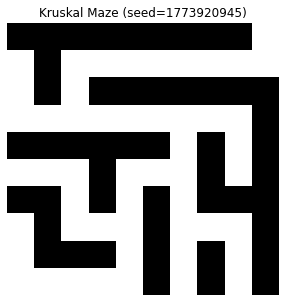

In [63]:
grid_rows = 2 * eff_rows
grid_cols = 2 * eff_cols
maze_2d = np.array(out_buf, dtype=np.uint8).reshape(MAX_GRID_ROWS, MAX_GRID_COLS)
active_raw = maze_2d[:grid_rows, :grid_cols].copy()

# Re-orient output so start appears at bottom-left and goal at top-right
oriented_maze_2d = np.flipud(active_raw)
binary_maze_1d = oriented_maze_2d.reshape(-1)


print(binary_maze_1d)
print(oriented_maze_2d)

if np.all(active_raw == 0xFF):
    print('Error')
    print('Error')

plt.figure(figsize=(5, 5))
plt.imshow(oriented_maze_2d, cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
plt.title(f'Kruskal Maze (seed={seed_value})')
plt.axis('off')
plt.show()

In [85]:
import requests
import numpy as np

# Convert the 1D array into the string format the website expects
grid_string = "".join(binary_maze_1d.astype(str))

payload = {
    "grid_data": grid_string,
    "rows": int(grid_rows),
    "cols": int(grid_cols),
    "maze_id": f"FPGA_MAZE_{seed_value}"
}

URL = "http://13.48.68.209:5000/sync_maze"

try:
    response = requests.post(URL, json=payload, timeout=10)
    if response.status_code == 200:
        print("Successfully synced maze to AWS")
        print("Server Response:", response.json())
    else:
        print(f"Failed with status code: {response.status_code}")
        print("Response text:", response.text)
except Exception as e:
    print(f"Network error: {e}")

Successfully synced maze to AWS
Server Response: {'id': 'FPGA_MAZE_1773920945', 'status': 'SUCCESS'}


In [65]:
from collections import deque

start = (0, 0)
goal = (grid_rows - 1, grid_cols - 1)

if active_raw[start] != 0 or active_raw[goal] != 0:
    print('Start or goal is blocked')
else:
    q = deque([start])
    seen = {start}
    steps = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    while q:
        r, c = q.popleft()
        if (r, c) == goal:
            break
        for dr, dc in steps:
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid_rows and 0 <= nc < grid_cols and active_raw[nr, nc] == 0 and (nr, nc) not in seen:
                seen.add((nr, nc))
                q.append((nr, nc))

    print('Goal reachable:', goal in seen)

Goal reachable: True


# PATH GENERATING

In [66]:

try:
    overlay = Overlay("/home/xilinx/jupyter_notebooks/bfs_with_pipelining/design.bit")
    print("    OK: Overlay loaded successfully")
except Exception as e:
    print(f"    ERROR loading overlay: {e}")
    raise



for name in overlay.ip_dict.keys():
    print(f"    - {name}")

    OK: Overlay loaded successfully
    - axi_dma_0
    - processing_system7_0


In [67]:


try:
    dma = overlay.axi_dma_0   
    print(f"    OK: DMA found: {dma}")
    print(f"    Send channel: {dma.sendchannel}")
    print(f"    Recv channel: {dma.recvchannel}")
except Exception as e:
    print(f"    ERROR: Could not find axi_dma_0: {e}")
    print("    Check the IP names printed in CELL 1 and update the name here")
    raise

    OK: DMA found: <pynq.lib.dma.DMA object at 0xa5d3f5e0>
    Send channel: <pynq.lib.dma._SDMAChannel object at 0xa5d3ff28>
    Recv channel: <pynq.lib.dma._SDMAChannel object at 0xa5d3f9b8>


In [68]:
#



maze = binary_maze_1d

assert len(maze) == 100, "Maze must be exactly 100 cells"

# Print maze visually for verification
print("    Maze layout (S=start row9col0, G=goal row0col9):")
for row in range(10):
    line = "    "
    for col in range(10):
        idx = row * 10 + col
        if row == 9 and col == 0:
            line += "S "
        elif row == 0 and col == 9:
            line += "G "
        elif maze[idx] == 1:
            line += "# "
        else:
            line += ". "
    print(line)

print(f"\n    Total cells: {len(maze)}")
print(f"    Wall count:  {sum(maze)}")

    Maze layout (S=start row9col0, G=goal row0col9):
    # # # # # # # # # G 
    . # . . . . . . . . 
    . # . # # # # # # # 
    . . . . . . . . . # 
    # # # # # # . # . # 
    . . . # . . . # . # 
    # # . # . # . # # # 
    . # . . . # . . . # 
    . # # # . # . # . # 
    S . . . . # . # . # 

    Total cells: 100
    Wall count:  49


In [69]:


try:
    # 100 x 32-bit words for maze input
    # Each word carries one maze cell in bit[0]: 1=wall, 0=free
    input_buffer = allocate(shape=(100,), dtype=np.uint32)
    print(f" input_buffer allocated: shape={input_buffer.shape}, dtype={input_buffer.dtype}")

    # 99 x 32-bit words for path output


    output_buffer = allocate(shape=(99,), dtype=np.uint32)
    print(f"output_buffer allocated: shape={output_buffer.shape}, dtype={output_buffer.dtype}")
except Exception as e:
    print(f"    error allocating buffers: {e}")
    raise

 input_buffer allocated: shape=(100,), dtype=uint32
output_buffer allocated: shape=(99,), dtype=uint32


In [70]:

for i in range(100):
    input_buffer[i] = maze[i]

print("    First 10 values in input_buffer:")
print(f"    {list(input_buffer[:10])}")
print("    Expected: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (row 0 all free)")

print("\n    Row 1 values (indices 10-19):")
print(f"    {list(input_buffer[10:20])}")
print("    Expected: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0] (row 1 walls)")

print("\n    Start cell (index 90):")
print(f"    {input_buffer[90]}")
print("    Expected: 0 (start is free)")

    First 10 values in input_buffer:
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
    Expected: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (row 0 all free)

    Row 1 values (indices 10-19):
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
    Expected: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0] (row 1 walls)

    Start cell (index 90):
    0
    Expected: 0 (start is free)


In [71]:

for i in range(99):
    output_buffer[i] = 0
print(f"  output_buffer cleared, first 5 values: {list(output_buffer[:5])}")


  output_buffer cleared, first 5 values: [0, 0, 0, 0, 0]


In [72]:

print("    Sending maze to hardware via DMA sendchannel")
print("    Waiting for path from hardware via DMA recvchannel")

try:
    dma.recvchannel.transfer(output_buffer)   # prepare to receive first
    dma.sendchannel.transfer(input_buffer)    # then send maze

    print("    Waiting for sendchannel to complete")
    dma.sendchannel.wait()
    print("    OK: sendchannel done — maze delivered to hardware")

    print("    Waiting for recvchannel to complete (hardware is running BFS)")
    timeout = 0.000000000000001  # seconds
    t0 = time.time()
    while not dma.recvchannel.idle:
        if time.time() - t0 > timeout:
            print("Raw output buffer (first 10 words):")
            print(list(output_buffer[:99]))
            print(f"\nDMA sendchannel idle: {dma.sendchannel.idle}")
            print(f"DMA recvchannel idle: {dma.recvchannel.idle}")
            print(f"    TIMEOUT after {timeout}s — hardware did not respond")
            break
        time.sleep(0.01)
    else:
        elapsed = time.time() - t0
        print(f"   recvchannel done in {elapsed:.3f}s")

except Exception as e:
    print(f"    error during DMA transfer: {e}")
    raise

    Sending maze to hardware via DMA sendchannel
    Waiting for path from hardware via DMA recvchannel
    Waiting for sendchannel to complete
    OK: sendchannel done — maze delivered to hardware
    Waiting for recvchannel to complete (hardware is running BFS)
   recvchannel done in 0.000s


In [73]:

print("Raw output buffer (first 10 words):")
print(list(output_buffer[:99]))
print(f"\nDMA sendchannel idle: {dma.sendchannel.idle}")
print(f"DMA recvchannel idle: {dma.recvchannel.idle}")

Raw output buffer (first 10 words):
[8, 8, 8, 8, 1, 1, 1, 1, 8, 8, 1, 1, 4, 4, 4, 4, 1, 1, 8, 8, 8, 8, 8, 8, 8, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

DMA sendchannel idle: True
DMA recvchannel idle: True


In [74]:


# One-hot
dir_map = {
    1: "UP",
    2: "DOWN",
    4: "LEFT",
    8: "RIGHT"
}

decoded_path = []

for i, val in enumerate(output_buffer):
    v = int(val)

    # stop at first zero if remaining entries are just padding
    if v == 0:
        break

    if v in dir_map:
        decoded_path.append(dir_map[v])
    else:
        decoded_path.append(f"UNKNOWN({v})")

print("Decoded path directions:")
print(decoded_path)

print("\nPath with step numbers:")
for i, step in enumerate(decoded_path, start=1):
    print(f"Step {i:2d}: {step}")

Decoded path directions:
['RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'UP', 'UP', 'UP', 'UP', 'RIGHT', 'RIGHT', 'UP', 'UP', 'LEFT', 'LEFT', 'LEFT', 'LEFT', 'UP', 'UP', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'UP']

Path with step numbers:
Step  1: RIGHT
Step  2: RIGHT
Step  3: RIGHT
Step  4: RIGHT
Step  5: UP
Step  6: UP
Step  7: UP
Step  8: UP
Step  9: RIGHT
Step 10: RIGHT
Step 11: UP
Step 12: UP
Step 13: LEFT
Step 14: LEFT
Step 15: LEFT
Step 16: LEFT
Step 17: UP
Step 18: UP
Step 19: RIGHT
Step 20: RIGHT
Step 21: RIGHT
Step 22: RIGHT
Step 23: RIGHT
Step 24: RIGHT
Step 25: RIGHT
Step 26: UP


# MOVEMENT

In [75]:

from pynq.overlays.base import BaseOverlay
#from pynq.lib.arduino import Arduino_IO

base = BaseOverlay("base.bit", download=True)


In [76]:

from pynq.lib.pmod import Pmod_IO

# Connect Left Motor to PMODA (pins 0 through 3)
right_pins = [Pmod_IO(base.PMODA, i, 'out') for i in range(4)]

# Connect Right Motor to PMODB (pins 0 through 3)
left_pins = [Pmod_IO(base.PMODB, i, 'out') for i in range(4)]

print("Motors successfully connected to PMOD headers")

Motors successfully connected to PMOD headers


In [77]:
%%microblaze base.ARDUINO
#include "i2c.h"

i2c mpu_device;
unsigned char mpu_addr = 0x68;

int init_mpu() {
    mpu_device = i2c_open_device(0); 
    
    unsigned char buf1[2] = {0x6B, 0x00};
    i2c_write(mpu_device, mpu_addr, buf1, 2);
    
    unsigned char buf2[2] = {0x1B, 0x00};
    i2c_write(mpu_device, mpu_addr, buf2, 2);
    
    unsigned char buf3[2] = {0x1A, 0x04};
    i2c_write(mpu_device, mpu_addr, buf3, 2);
    
    return 0;
}

int read_gyro_z() {
    unsigned char reg = 0x47; 
    unsigned char buf[2] = {0, 0};
    
    i2c_write(mpu_device, mpu_addr, &reg, 1);
    i2c_read(mpu_device, mpu_addr, buf, 2);
    
    short z_val = (buf[0] << 8) | buf[1];
    return (int)z_val;
}

In [78]:
#32
import time
import math

step_sequence = [
    [1, 0, 0, 1],
    [0, 0, 1, 1],
    [0, 1, 1, 0],
    [1, 1, 0, 0],
]

_fwd = [step_sequence[i]     for i in range(4)]
_rev = [step_sequence[3 - i] for i in range(4)]

def release_motors():
    for i in range(4):
        left_pins[i].write(0)
        right_pins[i].write(0)

def _step_both(step_idx, l_fwd, r_fwd):
    s = step_idx % 4
    l = _fwd[s] if l_fwd else _rev[s]
    r = _fwd[s] if r_fwd else _rev[s]
    left_pins[0].write(l[0]);  right_pins[0].write(r[0])
    left_pins[1].write(l[1]);  right_pins[1].write(r[1])
    left_pins[2].write(l[2]);  right_pins[2].write(r[2])
    left_pins[3].write(l[3]);  right_pins[3].write(r[3])

class MPU6500_FPGA:
    def __init__(self):
        init_mpu()
        time.sleep(0.3)
        self.z_offset = 0.0

    def calibrate(self, samples=200):
        print("Calibrating IMU, we keep rover perfectly still")
        total = 0.0
        count = 0
        for _ in range(samples):
            raw = read_gyro_z()
            if raw != 999999:
                total += raw
                count += 1
            time.sleep(0.01)
        self.z_offset = total / count if count > 0 else 0.0
        print(f"Calibration done. Offset: {self.z_offset:.3f} ({count}/{samples} good samples)")

    def get_dps(self):
        raw = read_gyro_z()
        if raw == 999999:
            return None
        return (raw - self.z_offset) / 131.0

imu = MPU6500_FPGA()
imu.calibrate()
print("Ready.")

SQUARE_SIZE_CM       = 17.0
WHEEL_DIAM_CM        = 6.0
STEPS_PER_REV        = 200
STEPS_PER_CM         = STEPS_PER_REV / (math.pi * WHEEL_DIAM_CM)
STEPS_PER_SQUARE     = int(SQUARE_SIZE_CM * STEPS_PER_CM)

TURN_TARGET_DEG      = 88.3
DRIFT_THRESHOLD_DEG  = 1.5
MIN_SNAP_DEG         = 1.5 
TURN_ERROR_THRESHOLD = 0.5
ADJUSTMENT_MINUS     = 0.2

CORRECTION_DELAY     = 0.006
DRIVE_DELAY          = 0.002
TURN_DELAY           = 0.003

absolute_heading = 0.0

def _nearest_grid(heading):
    return round(heading / 90.0) * 90.0

def _update_heading(delta):
    global absolute_heading
    absolute_heading += delta

def _heading_error():
    return absolute_heading - _nearest_grid(absolute_heading)

def _integrate_gyro(angle, last_ts):
    now = time.time()
    dt  = now - last_ts
    dps = imu.get_dps()
    if dps is not None:
        angle += dps * dt
    return angle, now
def gyro_turn(target_deg, l_fwd, r_fwd, delay=TURN_DELAY, _is_correction=False):

    angle    = 0.0
    step_idx = 0
    last_ts  = time.time()
    deadline = time.time() + 12.0

    while abs(angle) < target_deg:
        if time.time() > deadline:
            print(f"   turn timed out at {angle:.1f}° of {target_deg}°")
            break
        _step_both(step_idx, l_fwd, r_fwd)
        step_idx += 1
        angle, last_ts = _integrate_gyro(angle, last_ts)
        time.sleep(delay)

    release_motors()

    
    consecutive_still = 0
    coast_deadline = time.time() + 1.0
    while time.time() < coast_deadline:
        angle, last_ts = _integrate_gyro(angle, last_ts)
        dps = imu.get_dps()
        if dps is not None and abs(dps) < 2.0:
            consecutive_still += 1
        else:
            consecutive_still = 0
        if consecutive_still >= 3:
            break
        time.sleep(0.008)

    actual = abs(angle)
    print(f"  Turn complete: target={target_deg:.1f}° actual={actual:.1f}°")
    return actual

def _snap_to_grid():
    global absolute_heading
    error = _heading_error()
    if abs(error) < DRIFT_THRESHOLD_DEG:
        return

    
    correction = abs(error)
    if correction < MIN_SNAP_DEG:
        return

    print(f" Grid snap: heading={absolute_heading:.1f}° error={error:+.1f}°. Correcting")

    if error > 0:
        actual = gyro_turn(correction, True, False,
                           delay=CORRECTION_DELAY, _is_correction=True)
        absolute_heading -= actual
    else:
        actual = gyro_turn(correction, False, True,
                           delay=CORRECTION_DELAY, _is_correction=True)
        absolute_heading += actual

    print(f"  Snapped: absolute={absolute_heading:.1f}°")

def gyro_turn_intentional(target_deg, l_fwd, r_fwd):
    actual = gyro_turn(target_deg, l_fwd, r_fwd, delay=TURN_DELAY)

    turn_error = actual - target_deg
    if abs(turn_error) > TURN_ERROR_THRESHOLD:
        direction = "overshot" if turn_error > 0 else "undershot"
        print(f"  → {direction} by {turn_error:+.1f}°. Micro-correcting")
        correction_target = max(0, abs(turn_error) - ADJUSTMENT_MINUS)
        corr_actual = gyro_turn(correction_target,
                                not l_fwd if turn_error > 0 else l_fwd,
                                not r_fwd if turn_error > 0 else r_fwd,
                                delay=CORRECTION_DELAY,
                                _is_correction=True)
        if turn_error > 0:
            actual -= corr_actual
        else:
            actual += corr_actual

    signed_delta = -actual if (l_fwd and not r_fwd) else actual
    _update_heading(signed_delta)
    print(f"  absolute={absolute_heading:.1f}°")

    time.sleep(0.15)   # let chassis fully settle before snap
    _snap_to_grid()


def drive(steps, l_fwd=True, r_fwd=True, top_delay=DRIVE_DELAY):
    accel_steps = max(0, int(steps * 0.15))
    drift       = 0.0
    last_ts     = time.time()

    for s in range(steps):
        if s < accel_steps:
            frac  = s / accel_steps
            delay = 0.010 - (0.010 - top_delay) * frac
        elif s > steps - accel_steps:
            frac  = (s - (steps - accel_steps)) / max(accel_steps, 1)
            delay = top_delay + (0.010 - top_delay) * frac
        else:
            delay = top_delay

        _step_both(s, l_fwd, r_fwd)
        drift, last_ts = _integrate_gyro(drift, last_ts)
        time.sleep(delay)

    release_motors()
    time.sleep(0.30)

    _update_heading(drift)
    print(f"  Drive complete: drift={drift:+.1f}° absolute={absolute_heading:.1f}°")
    _snap_to_grid()


HEADING_MAP = {'UP': 0, 'RIGHT': 1, 'DOWN': 2, 'LEFT': 3}
current_heading = 0

def solve_maze(directions):
    global current_heading, absolute_heading

    start_time = time.time()
    absolute_heading = 0.0
    heading_names = {v: k for k, v in HEADING_MAP.items()}

    for raw_dir in directions:
        dir_str = raw_dir.strip().upper()
        if dir_str not in HEADING_MAP:
            continue

        target = HEADING_MAP[dir_str]
        turn_diff = (target - current_heading) % 4

        if turn_diff == 1:
            gyro_turn_intentional(TURN_TARGET_DEG, True, False)
        elif turn_diff == 2:
            gyro_turn_intentional(TURN_TARGET_DEG * 2, True, False)
        elif turn_diff == 3:
            gyro_turn_intentional(TURN_TARGET_DEG, False, True)

        current_heading = target
        drive(STEPS_PER_SQUARE)

    elapsed = time.time() - start_time
    total_steps = len(directions)
    
    trigger_celebration(elapsed, total_steps, absolute_heading)
    print(f"Maze complete. Final absolute heading: {absolute_heading:.1f}°")

release_motors()

Calibrating IMU, we keep rover perfectly still
Calibration done. Offset: -52.360 (200/200 good samples)
Ready.


In [79]:
current_heading = 0
# 0=Up, 1=Right, 2=Down, 3=Left

In [80]:
release_motors()

try:
    solve_maze(decoded_path)
except KeyboardInterrupt:
    release_motors()

  Turn complete: target=88.3° actual=88.8°
  → overshot by +0.5°. Micro-correcting
  Turn complete: target=0.3° actual=0.3°
  absolute=-88.5°
  Drive complete: drift=+0.5° absolute=-88.1°
 Grid snap: heading=-88.1° error=+1.9°. Correcting
  Turn complete: target=1.9° actual=2.1°
  Snapped: absolute=-90.1°
  Drive complete: drift=+2.1° absolute=-88.1°
 Grid snap: heading=-88.1° error=+1.9°. Correcting
  Turn complete: target=1.9° actual=2.2°
  Snapped: absolute=-90.3°
  Drive complete: drift=+1.6° absolute=-88.7°
  Drive complete: drift=+1.4° absolute=-87.3°
 Grid snap: heading=-87.3° error=+2.7°. Correcting
  Turn complete: target=2.7° actual=2.8°
  Snapped: absolute=-90.2°
  Turn complete: target=88.3° actual=89.2°
  → overshot by +0.9°. Micro-correcting
  Turn complete: target=0.7° actual=0.8°
  absolute=-1.8°
 Grid snap: heading=-1.8° error=-1.8°. Correcting
  Turn complete: target=1.8° actual=2.1°
  Snapped: absolute=0.3°
  Drive complete: drift=+0.7° absolute=1.0°
  Drive complete

NameError: name 'trigger_celebration' is not defined

# zero the maze temporarily

In [39]:
#zero maze
zero_array = np.zeros(100, dtype=np.uint8)


zero_string = "".join(zero_array.astype(str))

payload = {
    "grid_data": zero_string,
    "rows": int(grid_rows),
    "cols": int(grid_cols),
    "maze_id": f"FPGA_MAZE_{seed_value}"
}

URL = "http://13.48.68.209:5000/sync_maze"

try:
    response = requests.post(URL, json=payload, timeout=10)
    if response.status_code == 200:
        print("Server Response:", response.json())
    else:
        print(f"Failed with status code: {response.status_code}")
        print("Response text:", response.text)
except Exception as e:
    print(f"Network error: {e}")

Server Response: {'id': 'FPGA_MAZE_1773918579', 'status': 'SUCCESS'}


In [40]:
#bring the maze back

grid_string = "".join(binary_maze_1d.astype(str))

payload = {
    "grid_data": grid_string,
    "rows": int(grid_rows),
    "cols": int(grid_cols),
    "maze_id": f"FPGA_MAZE_{seed_value}"
}

URL = "http://13.48.68.209:5000/sync_maze"

try:
    response = requests.post(URL, json=payload, timeout=10)
    if response.status_code == 200:
        print("Server Response:", response.json())
    else:
        print(f"Failed with status code: {response.status_code}")
        print("Response text:", response.text)
except Exception as e:
    print(f"Network error: {e}")

Server Response: {'id': 'FPGA_MAZE_1773918579', 'status': 'SUCCESS'}


# a wall turns into a free space when object detected on it

[{'gx': '0', 'gy': '6'}, {'gx': '3', 'gy': '2'}, {'gx': '0', 'gy': '4'}]
[1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0
 0 0 1 0 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0
 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1]
[[1 1 1 1 1 1 1 1 1 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 1 1 1 1 0 1 0 1]
 [0 0 0 1 0 0 0 1 0 1]
 [0 1 0 1 0 1 0 1 1 1]
 [0 1 0 0 0 1 0 0 0 1]
 [0 1 1 1 0 1 0 1 0 1]
 [0 0 0 0 0 1 0 1 0 1]]


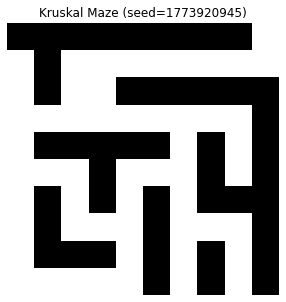

In [86]:
import requests

SERVER = "http://13.48.68.209:5000"
resp = requests.get(f'{SERVER}/get_positions', timeout=2)
positions = resp.json()['positions']

print(positions)
new_positions = [[int(p['gx']), int(p['gy'])] for p in positions]


binary_maze_1d_corrected = binary_maze_1d.copy()
active_raw_corrected = active_raw.copy()

for new_pos in new_positions:
    binary_maze_1d_corrected[10 * new_pos[1] + new_pos[0]] = 0
    active_raw_corrected[9 - new_pos[1], new_pos[0]] = 0

oriented_maze_2d_corrected = np.flipud(active_raw_corrected)
print(binary_maze_1d_corrected)
print(oriented_maze_2d_corrected)

if np.all(active_raw_corrected == 0xFF):
    print('Error')

plt.figure(figsize=(5, 5))
plt.imshow(oriented_maze_2d_corrected, cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
plt.title(f'Kruskal Maze (seed={seed_value})')
plt.axis('off')
plt.show()

In [87]:
import numpy as np


grid_string = "".join(binary_maze_1d_corrected.astype(str))

payload = {
    "grid_data": grid_string,
    "rows": int(grid_rows),
    "cols": int(grid_cols),
    "maze_id": f"FPGA_MAZE_{seed_value}"
}

URL = "http://13.48.68.209:5000/sync_maze"

try:
    response = requests.post(URL, json=payload, timeout=10)
    if response.status_code == 200:
        print("Server Response:", response.json())
    else:
        print(f"Failed with status code: {response.status_code}")
        print("Response text:", response.text)
except Exception as e:
    print(f"Network error: {e}")

Server Response: {'id': 'FPGA_MAZE_1773920945', 'status': 'SUCCESS'}


In [88]:
from collections import deque

start = (0, 0)
goal = (grid_rows - 1, grid_cols - 1)

if active_raw_corrected[start] != 0 or active_raw_corrected[goal] != 0:
    print('Start or goal is blocked')
else:
    q = deque([start])
    seen = {start}
    steps = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    while q:
        r, c = q.popleft()
        if (r, c) == goal:
            break
        for dr, dc in steps:
            nr, nc = r + dr, c + dc
            if 0 <= nr < grid_rows and 0 <= nc < grid_cols and active_raw[nr, nc] == 0 and (nr, nc) not in seen:
                seen.add((nr, nc))
                q.append((nr, nc))

    print('Goal reachable:', goal in seen)

Goal reachable: True


# new path finding

In [ ]:

try:
    overlay = Overlay("/home/xilinx/jupyter_notebooks/bfs_with_pipelining/design.bit")
    print("Overlay loaded successfully")
except Exception as e:
    print(f"    error loading overlay: {e}")
    raise


for name in overlay.ip_dict.keys():
    print(f"    - {name}")

Overlay loaded successfully
    - axi_dma_0
    - processing_system7_0


In [45]:

try:
    dma = overlay.axi_dma_0  
    print(f"    DMA found: {dma}")
    print(f"    Send channel: {dma.sendchannel}")
    print(f"    Recv channel: {dma.recvchannel}")
except Exception as e:
    print(f"    ERROR: Could not find axi_dma_0: {e}")
    print("    Check the IP names printed in CELL 1 and update the name here")
    raise

    DMA found: <pynq.lib.dma.DMA object at 0xa9da9b20>
    Send channel: <pynq.lib.dma._SDMAChannel object at 0xa8d80640>
    Recv channel: <pynq.lib.dma._SDMAChannel object at 0xa9da9d48>


In [46]:

maze = binary_maze_1d_corrected

assert len(maze) == 100, "Maze must be exactly 100 cells"
print("    Maze layout (S=start row9col0, G=goal row0col9):")
for row in range(10):
    line = "    "
    for col in range(10):
        idx = row * 10 + col
        if row == 9 and col == 0:
            line += "S "
        elif row == 0 and col == 9:
            line += "G "
        elif maze[idx] == 1:
            line += "# "
        else:
            line += ". "
    print(line)

print(f"\n    Total cells: {len(maze)}")
print(f"    Wall count:  {sum(maze)}")
print(f"    Free count:  {maze.count(0)}")

    Maze layout (S=start row9col0, G=goal row0col9):
    # # # # # # # # # G 
    . . . . . . . . . . 
    . # . # . # # # . # 
    . . . # . # . . . # 
    . . # # # # # # . # 
    . # . # . # . . . # 
    . # . # . # . # . # 
    . # . . . . . # . # 
    . # # # . # . # . # 
    S . . . . # . # . # 

    Total cells: 100
    Wall count:  46


AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [47]:

try:
    input_buffer = allocate(shape=(100,), dtype=np.uint32)
    print(f"    OK: input_buffer allocated: shape={input_buffer.shape}, dtype={input_buffer.dtype}")

    output_buffer = allocate(shape=(99,), dtype=np.uint32)
    print(f"    OK: output_buffer allocated: shape={output_buffer.shape}, dtype={output_buffer.dtype}")
except Exception as e:
    print(f"    ERROR allocating buffers: {e}")
    raise

    OK: input_buffer allocated: shape=(100,), dtype=uint32
    OK: output_buffer allocated: shape=(99,), dtype=uint32


In [48]:

for i in range(100):
    input_buffer[i] = maze[i]

print("    First 10 values in input_buffer:")
print(f"    {list(input_buffer[:10])}")
print("    Expected: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (row 0 all free)")

print("\n    Row 1 values (indices 10-19):")
print(f"    {list(input_buffer[10:20])}")
print("    Expected: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0] (row 1 walls)")

print("\n    Start cell (index 90):")
print(f"    {input_buffer[90]}")
print("    Expected: 0 (start is free)")

    First 10 values in input_buffer:
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
    Expected: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (row 0 all free)

    Row 1 values (indices 10-19):
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    Expected: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0] (row 1 walls)

    Start cell (index 90):
    0
    Expected: 0 (start is free)


In [49]:

for i in range(99):
    output_buffer[i] = 0
print(f"    OK: output_buffer cleared, first 5 values: {list(output_buffer[:5])}")


    OK: output_buffer cleared, first 5 values: [0, 0, 0, 0, 0]


In [50]:

print("    Sending maze to hardware via DMA sendchannel")
print("    Waiting for path from hardware via DMA recvchannel")

try:
    dma.recvchannel.transfer(output_buffer)   # prepare to receive first
    dma.sendchannel.transfer(input_buffer)    # then send maze

    print("    Waiting for sendchannel to complete...")
    dma.sendchannel.wait()
    print("    OK: sendchannel done — maze delivered to hardware")

    print("    Waiting for recvchannel to complete (hardware is running BFS)...")
    timeout = 0.000000000000001  # seconds
    t0 = time.time()
    while not dma.recvchannel.idle:
        if time.time() - t0 > timeout:
            print("Raw output buffer (first 10 words):")
            print(list(output_buffer[:99]))
            print(f"\nDMA sendchannel idle: {dma.sendchannel.idle}")
            print(f"DMA recvchannel idle: {dma.recvchannel.idle}")
            print(f"    TIMEOUT after {timeout}s — hardware did not respond")

            break
        time.sleep(0.01)
    else:
        elapsed = time.time() - t0
        print(f" recvchannel done in {elapsed:.3f}s")

except Exception as e:
    print(f"    error: {e}")
    raise

    Sending maze to hardware via DMA sendchannel
    Waiting for path from hardware via DMA recvchannel
    Waiting for sendchannel to complete...
    OK: sendchannel done — maze delivered to hardware
    Waiting for recvchannel to complete (hardware is running BFS)...
 recvchannel done in 0.000s


In [51]:
#8
print("Raw output buffer (first 10 words):")
print(list(output_buffer[:99]))

# Check DMA status
print(f"\nDMA sendchannel idle: {dma.sendchannel.idle}")
print(f"DMA recvchannel idle: {dma.recvchannel.idle}")

Raw output buffer (first 10 words):
[1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

DMA sendchannel idle: True
DMA recvchannel idle: True


In [52]:


dir_map = {
    1: "UP",
    2: "DOWN",
    4: "LEFT",
    8: "RIGHT"
}

decoded_path = []

for i, val in enumerate(output_buffer):
    v = int(val)
    if v == 0:
        break

    if v in dir_map:
        decoded_path.append(dir_map[v])
    else:
        decoded_path.append(f"UNKNOWN({v})")

print("Decoded path directions:")
print(decoded_path)

print("\nPath with step numbers:")
for i, step in enumerate(decoded_path, start=1):
    print(f"Step {i:2d}: {step}")

Decoded path directions:
['UP', 'UP', 'UP', 'UP', 'UP', 'UP', 'UP', 'UP', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'RIGHT', 'UP']

Path with step numbers:
Step  1: UP
Step  2: UP
Step  3: UP
Step  4: UP
Step  5: UP
Step  6: UP
Step  7: UP
Step  8: UP
Step  9: RIGHT
Step 10: RIGHT
Step 11: RIGHT
Step 12: RIGHT
Step 13: RIGHT
Step 14: RIGHT
Step 15: RIGHT
Step 16: RIGHT
Step 17: RIGHT
Step 18: UP


# movement in new maze

In [53]:

from pynq.overlays.base import BaseOverlay


base = BaseOverlay("base.bit", download=True)



In [54]:

from pynq.lib.pmod import Pmod_IO


right_pins = [Pmod_IO(base.PMODA, i, 'out') for i in range(4)]


left_pins = [Pmod_IO(base.PMODB, i, 'out') for i in range(4)]



In [55]:
%%microblaze base.ARDUINO
#include "i2c.h"

i2c mpu_device;
unsigned char mpu_addr = 0x68;

int init_mpu() {
    mpu_device = i2c_open_device(0); 
    
    unsigned char buf1[2] = {0x6B, 0x00};
    i2c_write(mpu_device, mpu_addr, buf1, 2);
    
    unsigned char buf2[2] = {0x1B, 0x00};
    i2c_write(mpu_device, mpu_addr, buf2, 2);
    
    unsigned char buf3[2] = {0x1A, 0x04};
    i2c_write(mpu_device, mpu_addr, buf3, 2);
    
    return 0;
}

int read_gyro_z() {
    unsigned char reg = 0x47; 
    unsigned char buf[2] = {0, 0};
    
    i2c_write(mpu_device, mpu_addr, &reg, 1);
    i2c_read(mpu_device, mpu_addr, buf, 2);
    
    short z_val = (buf[0] << 8) | buf[1];
    return (int)z_val;
}

In [56]:

import time
import math


step_sequence = [
    [1, 0, 0, 1],
    [0, 0, 1, 1],
    [0, 1, 1, 0],
    [1, 1, 0, 0],
]

_fwd = [step_sequence[i]     for i in range(4)]
_rev = [step_sequence[3 - i] for i in range(4)]

def release_motors():
    for i in range(4):
        left_pins[i].write(0)
        right_pins[i].write(0)

def _step_both(step_idx, l_fwd, r_fwd):
    s = step_idx % 4
    l = _fwd[s] if l_fwd else _rev[s]
    r = _fwd[s] if r_fwd else _rev[s]
    left_pins[0].write(l[0]);  right_pins[0].write(r[0])
    left_pins[1].write(l[1]);  right_pins[1].write(r[1])
    left_pins[2].write(l[2]);  right_pins[2].write(r[2])
    left_pins[3].write(l[3]);  right_pins[3].write(r[3])


class MPU6500_FPGA:
    def __init__(self):
        init_mpu()
        time.sleep(0.3)
        self.z_offset = 0.0

    def calibrate(self, samples=200):
        print("Calibrating IMU... keep rover perfectly still!")
        total = 0.0
        count = 0
        for _ in range(samples):
            raw = read_gyro_z()
            if raw != 999999:
                total += raw
                count += 1
            time.sleep(0.01)
        self.z_offset = total / count if count > 0 else 0.0
        print(f"Calibration done. Offset: {self.z_offset:.3f} ({count}/{samples} good samples)")

    def get_dps(self):
        raw = read_gyro_z()
        if raw == 999999:
            return None
        return (raw - self.z_offset) / 131.0

imu = MPU6500_FPGA()
imu.calibrate()
print("Ready.")


SQUARE_SIZE_CM       = 16.5
WHEEL_DIAM_CM        = 6.0
STEPS_PER_REV        = 200
STEPS_PER_CM         = STEPS_PER_REV / (math.pi * WHEEL_DIAM_CM)
STEPS_PER_SQUARE     = int(SQUARE_SIZE_CM * STEPS_PER_CM)

TURN_TARGET_DEG      = 88.3
DRIFT_THRESHOLD_DEG  = 1.5
MIN_SNAP_DEG         = 1.5 
TURN_ERROR_THRESHOLD = 0.5
ADJUSTMENT_MINUS     = 0.2

CORRECTION_DELAY     = 0.006
DRIVE_DELAY          = 0.002
TURN_DELAY           = 0.003


absolute_heading = 0.0

def _nearest_grid(heading):
    return round(heading / 90.0) * 90.0

def _update_heading(delta):
    global absolute_heading
    absolute_heading += delta

def _heading_error():
    return absolute_heading - _nearest_grid(absolute_heading)


def _integrate_gyro(angle, last_ts):
    now = time.time()
    dt  = now - last_ts
    dps = imu.get_dps()
    if dps is not None:
        angle += dps * dt
    return angle, now


def gyro_turn(target_deg, l_fwd, r_fwd, delay=TURN_DELAY, _is_correction=False):

    angle    = 0.0
    step_idx = 0
    last_ts  = time.time()
    deadline = time.time() + 12.0

    while abs(angle) < target_deg:
        if time.time() > deadline:
            print(f"  WARNING: turn timed out at {angle:.1f}° of {target_deg}°")
            break
        _step_both(step_idx, l_fwd, r_fwd)
        step_idx += 1
        angle, last_ts = _integrate_gyro(angle, last_ts)
        time.sleep(delay)

    release_motors()


    consecutive_still = 0
    coast_deadline = time.time() + 1.0
    while time.time() < coast_deadline:
        angle, last_ts = _integrate_gyro(angle, last_ts)
        dps = imu.get_dps()
        if dps is not None and abs(dps) < 2.0:
            consecutive_still += 1
        else:
            consecutive_still = 0
        if consecutive_still >= 3:
            break
        time.sleep(0.008)

    actual = abs(angle)
    print(f"  Turn complete: target={target_deg:.1f}° actual={actual:.1f}°")
    return actual


def _snap_to_grid():
    global absolute_heading
    error = _heading_error()
    if abs(error) < DRIFT_THRESHOLD_DEG:
        return


    correction = abs(error)
    if correction < MIN_SNAP_DEG:
        return

    print(f" Grid snap: heading={absolute_heading:.1f}° error={error:+.1f}°. Correcting")

    if error > 0:
        actual = gyro_turn(correction, True, False,
                           delay=CORRECTION_DELAY, _is_correction=True)
        absolute_heading -= actual
    else:
        actual = gyro_turn(correction, False, True,
                           delay=CORRECTION_DELAY, _is_correction=True)
        absolute_heading += actual

    print(f"  Snapped: absolute={absolute_heading:.1f}°")


def gyro_turn_intentional(target_deg, l_fwd, r_fwd):
    actual = gyro_turn(target_deg, l_fwd, r_fwd, delay=TURN_DELAY)

    turn_error = actual - target_deg
    if abs(turn_error) > TURN_ERROR_THRESHOLD:
        direction = "overshot" if turn_error > 0 else "undershot"
        print(f"  → {direction} by {turn_error:+.1f}°. Micro-correcting…")
        correction_target = max(0, abs(turn_error) - ADJUSTMENT_MINUS)
        corr_actual = gyro_turn(correction_target,
                                not l_fwd if turn_error > 0 else l_fwd,
                                not r_fwd if turn_error > 0 else r_fwd,
                                delay=CORRECTION_DELAY,
                                _is_correction=True)
        if turn_error > 0:
            actual -= corr_actual
        else:
            actual += corr_actual

    signed_delta = -actual if (l_fwd and not r_fwd) else actual
    _update_heading(signed_delta)
    print(f"  absolute={absolute_heading:.1f}°")

    time.sleep(0.15)   
    _snap_to_grid()


def drive(steps, l_fwd=True, r_fwd=True, top_delay=DRIVE_DELAY):
    accel_steps = max(0, int(steps * 0.15))
    drift       = 0.0
    last_ts     = time.time()

    for s in range(steps):
        if s < accel_steps:
            frac  = s / accel_steps
            delay = 0.010 - (0.010 - top_delay) * frac
        elif s > steps - accel_steps:
            frac  = (s - (steps - accel_steps)) / max(accel_steps, 1)
            delay = top_delay + (0.010 - top_delay) * frac
        else:
            delay = top_delay

        _step_both(s, l_fwd, r_fwd)
        drift, last_ts = _integrate_gyro(drift, last_ts)
        time.sleep(delay)

    release_motors()
    time.sleep(0.30)

    _update_heading(drift)
    print(f"  Drive complete: drift={drift:+.1f}° absolute={absolute_heading:.1f}°")
    _snap_to_grid()


HEADING_MAP = {'UP': 0, 'RIGHT': 1, 'DOWN': 2, 'LEFT': 3}
current_heading = 0

def solve_maze(directions):
    global current_heading, absolute_heading

    start_time = time.time()
    absolute_heading = 0.0
    heading_names = {v: k for k, v in HEADING_MAP.items()}

    for raw_dir in directions:
        dir_str = raw_dir.strip().upper()
        if dir_str not in HEADING_MAP:
            continue

        target = HEADING_MAP[dir_str]
        turn_diff = (target - current_heading) % 4

        if turn_diff == 1:
            gyro_turn_intentional(TURN_TARGET_DEG, True, False)
        elif turn_diff == 2:
            gyro_turn_intentional(TURN_TARGET_DEG * 2, True, False)
        elif turn_diff == 3:
            gyro_turn_intentional(TURN_TARGET_DEG, False, True)

        current_heading = target
        drive(STEPS_PER_SQUARE)

    elapsed = time.time() - start_time
    total_steps = len(directions)
    

    print(f"Maze complete. Final absolute heading: {absolute_heading:.1f}°")

release_motors()

Calibrating IMU... keep rover perfectly still!
Calibration done. Offset: -49.485 (200/200 good samples)
Ready.


In [57]:
current_heading = 0
# 0=Up, 1=Right, 2=Down, 3=Left

In [58]:
release_motors()

try:
    solve_maze(decoded_path)
except KeyboardInterrupt:
    print("\nEmergency Stop Triggered!")
    release_motors()

  Drive complete: drift=+2.2° absolute=2.2°
 Grid snap: heading=2.2° error=+2.2°. Correcting
  Turn complete: target=2.2° actual=2.4°
  Snapped: absolute=-0.2°
  Drive complete: drift=+1.6° absolute=1.4°
  Drive complete: drift=+1.5° absolute=2.9°
 Grid snap: heading=2.9° error=+2.9°. Correcting
  Turn complete: target=2.9° actual=3.2°
  Snapped: absolute=-0.2°
  Drive complete: drift=+1.5° absolute=1.3°
  Drive complete: drift=+1.4° absolute=2.7°
 Grid snap: heading=2.7° error=+2.7°. Correcting
  Turn complete: target=2.7° actual=2.9°
  Snapped: absolute=-0.2°
  Drive complete: drift=+1.0° absolute=0.8°
  Drive complete: drift=-0.1° absolute=0.7°
  Drive complete: drift=+1.0° absolute=1.7°
 Grid snap: heading=1.7° error=+1.7°. Correcting
  Turn complete: target=1.7° actual=2.0°
  Snapped: absolute=-0.3°
  Turn complete: target=88.3° actual=89.1°
  → overshot by +0.8°. Micro-correcting…
  Turn complete: target=0.6° actual=0.8°
  absolute=-88.6°
  Drive complete: drift=+2.0° absolute=-8